### Audio automatic labeling

To do the labeling the features to extract the information are:
- Short-time Energy
- Envelope Detection
- Spectral Flux

The audio folder will serve as an intput of informations, then applying this three methods of feature extraction, the information regarding the sudden change on the audio .wav will be recorded into a csv file with information of the time and respective feature.

In [5]:
!pip install pandas

  Using cached pytz-2024.2-py2.py3-none-any.whl.metadata (22 kB)
   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.6 MB 3.4 MB/s eta 0:00:04
   ---- ----------------------------------- 1.3/11.6 MB 4.2 MB/s eta 0:00:03
   ------- -------------------------------- 2.1/11.6 MB 3.6 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/11.6 MB 4.0 MB/s eta 0:00:03
   ----------------- ---------------------- 5.0/11.6 MB 4.9 MB/s eta 0:00:02
   -------------------- ------------------- 6.0/11.6 MB 5.0 MB/s eta 0:00:02
   --------------------------- ------------ 7.9/11.6 MB 5.5 MB/s eta 0:00:01
   --------------------------------- ------ 9.7/11.6 MB 6.0 MB/s eta 0:00:01
   -------------------------------------- - 11.3/11.6 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 11.6/11.6 MB 6.1 MB/s eta 0:00:00
Using cached pytz-2024.2-py2.py3-none-any.whl (508 kB)


In [6]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert, find_peaks

In [7]:
def compute_features(audio_path, sr=44100, frame_length=1024, hop_length=512):
    y, sr = librosa.load(audio_path, sr=sr)
    time = np.arange(len(y)) / sr
    
    # Short-Time Energy (STE)
    energy = np.array([
        np.sum(np.abs(y[i:i+frame_length])**2)
        for i in range(0, len(y), hop_length)
    ])
    
    # Envelope Detection
    analytic_signal = hilbert(y)
    envelope = np.abs(analytic_signal)
    envelope_smoothed = np.convolve(envelope, np.ones(1000)/1000, mode='same')
    
    # Spectral Flux
    spectrogram = np.abs(librosa.stft(y, n_fft=2048, hop_length=hop_length))
    spectral_flux = np.sqrt(np.sum(np.diff(spectrogram, axis=1)**2, axis=0))
    
    # Find Peaks (change points)
    energy_peaks, _ = find_peaks(energy, height=np.mean(energy) + 1.5 * np.std(energy))
    envelope_peaks, _ = find_peaks(envelope_smoothed, height=np.mean(envelope_smoothed) + 1.5 * np.std(envelope_smoothed))
    spectral_peaks, _ = find_peaks(spectral_flux, height=np.mean(spectral_flux) + 1.5 * np.std(spectral_flux))
    
    # Convert frame indices to time
    def get_time_intervals(peaks, hop_length, sr):
        intervals = []
        start = None
        for t in peaks * hop_length / sr:
            if start is None:
                start = t
            elif t - start > 0.1:  # Minimum duration to consider separate event
                intervals.append((start, t))
                start = None
        if start is not None:
            intervals.append((start, start))
        return intervals
    
    energy_intervals = get_time_intervals(energy_peaks, hop_length, sr)
    envelope_intervals = get_time_intervals(envelope_peaks, hop_length, sr)
    spectral_intervals = get_time_intervals(spectral_peaks, hop_length, sr)
    
    return energy_intervals, envelope_intervals, spectral_intervals

def process_audio_files(input_folder, output_csv):
    results = []
    for filename in os.listdir(input_folder):
        if filename.endswith(".wav"):
            file_path = os.path.join(input_folder, filename)
            energy_intervals, envelope_intervals, spectral_intervals = compute_features(file_path)
            
            for start, end in energy_intervals:
                results.append({"Filename": filename, "Start Time (s)": start, "End Time (s)": end, "Detected Feature": "Energy"})
            for start, end in envelope_intervals:
                results.append({"Filename": filename, "Start Time (s)": start, "End Time (s)": end, "Detected Feature": "Envelope"})
            for start, end in spectral_intervals:
                results.append({"Filename": filename, "Start Time (s)": start, "End Time (s)": end, "Detected Feature": "Spectral Flux"})
    
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    print(f"Results saved to {output_csv}")

input_folder = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples" # Folder containing .wav files
output_csv = "tempos_deglutiçao.csv"
process_audio_files(input_folder, output_csv)


Results saved to tempos_deglutiçao.csv


In [2]:
import pandas as pd

df = pd.read_csv('tempos_deglutiçao.csv')
df

,Filename,Start Time (s),End Time (s),Detected Feature
0,GC_F1-10ml.wav,2.821224,3.076644,Energy
1,GC_F1-10ml.wav,3.297234,3.297234,Energy
2,GC_F1-10ml.wav,1437.187483,1450.573787,Envelope
3,GC_F1-10ml.wav,1452.001814,1545.659501,Envelope
4,GC_F1-10ml.wav,1554.692063,1558.244717,Envelope
...,...,...,...,...
407,GE_M1_5ml.wav,5.921088,6.420317,Spectral Flux
408,GE_M1_5ml.wav,6.466757,8.359184,Spectral Flux
409,GE_M1_5ml.wav,8.382404,8.939683,Spectral Flux
410,GE_M1_5ml.wav,8.962902,10.983039,Spectral Flux


In [8]:
df = pd.read_csv("tempos_deglutiçao.csv")
print(df.columns)


Index(['Filename', 'Start Time (s)', 'End Time (s)', 'Detected Feature'], dtype='object')


In [14]:
df = pd.read_csv("tempos_deglutiçao.csv")
df.rename(columns={"Start Time (s)": "start_time", "End Time (s)": "end_time"}, inplace=True)

print(df.columns)  # Check if renaming worked

Index(['Filename', 'start_time', 'end_time', 'Detected Feature'], dtype='object')


In [15]:
df.columns = df.columns.str.strip()  # Remove extra spaces
print(df.columns)

Index(['Filename', 'start_time', 'end_time', 'Detected Feature'], dtype='object')


In [16]:
print(df.iloc[0])  # Prints the first row

Filename            GC_F1-10ml.wav
start_time                2.821224
end_time                  3.076644
Detected Feature            Energy
Name: 0, dtype: object


In [17]:
df.columns = ["Filename", "start_time", "end_time", "Detected Feature"]

In [19]:
print(df.iloc[2]) 

Filename            GC_F1-10ml.wav
Start Time (s)         1437.187483
End Time (s)           1450.573787
Detected Feature          Envelope
Name: 2, dtype: object


KeyError: 'start_time'

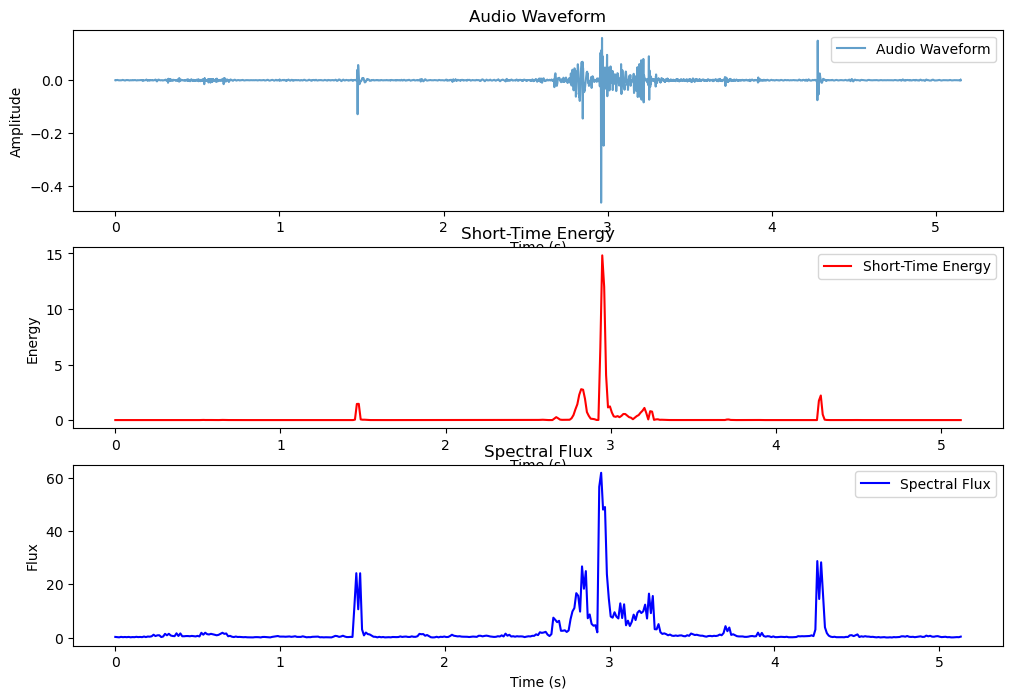

In [18]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# Load CSV with detected changes
df = pd.read_csv("tempos_deglutiçao.csv")

# Load Audio File
audio_file = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC_F1-3ml.wav" # File path
y, sr = librosa.load(audio_file, sr=44100)
time = np.arange(len(y)) / sr

# Compute Short-Time Energy (STE)
frame_length = 1024
hop_length = 512
energy = np.array([
    np.sum(np.abs(y[i:i + frame_length]) ** 2)
    for i in range(0, len(y) - frame_length, hop_length)
])
energy_time = np.arange(len(energy)) * hop_length / sr

# Compute Envelope
analytic_signal = hilbert(y)
envelope = np.abs(analytic_signal)

# Compute Spectral Flux
spectrogram = np.abs(librosa.stft(y, n_fft=2048, hop_length=hop_length))
spectral_flux = np.sqrt(np.sum(np.diff(spectrogram, axis=1) ** 2, axis=0))
spectral_time = np.arange(len(spectral_flux)) * hop_length / sr

# Create Figure
plt.figure(figsize=(12, 8))

# Plot Audio Waveform
plt.subplot(3, 1, 1)
plt.plot(time, y, label="Audio Waveform", alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Audio Waveform")
plt.legend()

# Plot Short-Time Energy with Highlighted Intervals
plt.subplot(3, 1, 2)
plt.plot(energy_time, energy, label="Short-Time Energy", color="r")
plt.xlabel("Time (s)")
plt.ylabel("Energy")
plt.title("Short-Time Energy")
plt.legend()

# Plot Spectral Flux with Highlighted Intervals
plt.subplot(3, 1, 3)
plt.plot(spectral_time, spectral_flux, label="Spectral Flux", color="b")
plt.xlabel("Time (s)")
plt.ylabel("Flux")
plt.title("Spectral Flux")
plt.legend()

# Highlight Detected Change Intervals
for _, row in df.iterrows():
    start, end = row["start_time"], row["end_time"] 
    plt.subplot(3, 1, 2)  # Highlight on Short-Time Energy plot
    plt.axvspan(start, end, color="red", alpha=0.3, label="Detected Change" if _ == 0 else "")
    plt.subplot(3, 1, 3)  # Highlight on Spectral Flux plot
    plt.axvspan(start, end, color="blue", alpha=0.3, label="Detected Change" if _ == 0 else "")

plt.tight_layout()
plt.show()
